In [35]:
from love_island_experiment import LoveIslandExperimentResults
from love_island_loaders import LoveIslandPerson
from matplotlib import pyplot as plt
import numpy as np


In [36]:
with open("../results/love_island_experiment_results.json", "r") as f:
    results = LoveIslandExperimentResults.model_validate_json(f.read())

results.agents
results.epoch_results
results.finale_pairs

[('patricie-herlikova', 'jan-michalek'),
 ('kristina-vargova', 'dusan-kajaba'),
 ('adriana-kristofova', 'jan-pesek'),
 ('michelle-ptasinska', 'martin-mikus')]

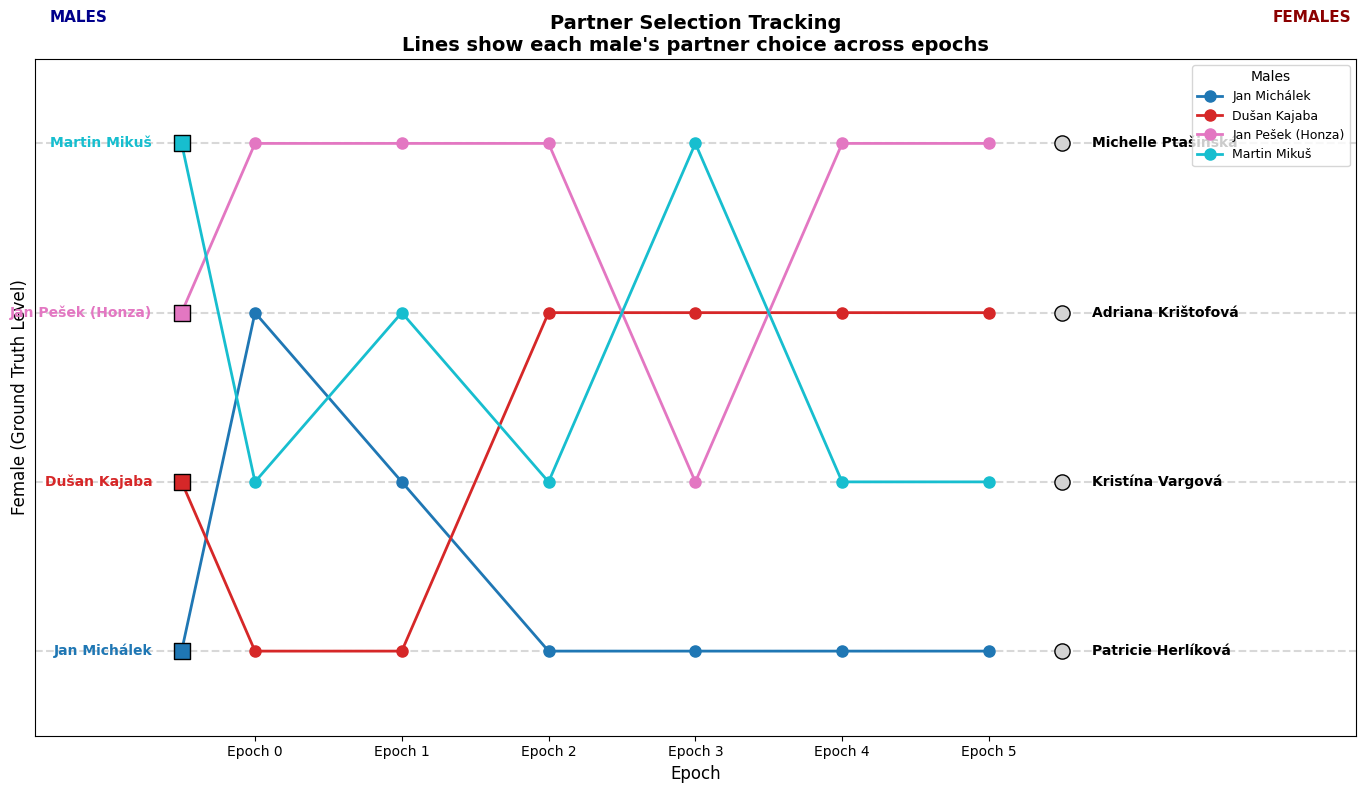

In [ ]:
# Partner Selection Tracking Plot
# Males on left, females on right, horizontal lines = ground truth (finale pairs)
# Lines show which female each male chose at each epoch (y = female level)

# Build lookup dictionaries
agent_by_id: dict[str, LoveIslandPerson] = {agent.id: agent for agent in results.agents}
female_ids: list[str] = [pair[0] for pair in results.finale_pairs]
male_ids: list[str] = [pair[1] for pair in results.finale_pairs]

# Y-position for each female (level)
female_level: dict[str, int] = {fid: i for i, fid in enumerate(female_ids)}

# Ground truth level for each male (their finale partner's level)
male_ground_truth_level: dict[str, int] = {
    mid: i for i, (fid, mid) in enumerate(results.finale_pairs)
}

# Agent names
female_names: list[str] = [agent_by_id[fid].full_name for fid in female_ids]
male_names: list[str] = [agent_by_id[mid].full_name for mid in male_ids]

# Setup plot
fig, ax = plt.subplots(figsize=(14, 8))
epochs: list[int] = [er.epoch for er in results.epoch_results]
num_epochs: int = len(epochs)

# Color palette: one color per male
colors = plt.cm.tab10(np.linspace(0, 1, len(male_ids)))
male_colors: dict[str, tuple] = {
    mid: tuple(colors[i]) for i, mid in enumerate(male_ids)
}

# Plot each male's partner selection as a line (y = which female was chosen)
for male_id in male_ids:
    partner_history = [er.agent_partners.get(male_id) for er in results.epoch_results]
    y_coords = [female_level.get(pid, -1) for pid in partner_history]
    color = male_colors[male_id]

    # Connecting line from male box (ground truth level) to first data point
    ground_truth_y = male_ground_truth_level[male_id]
    ax.plot(
        [-0.5, epochs[0]],
        [ground_truth_y, y_coords[0]],
        color=color,
        linewidth=2,
        zorder=2,
    )

    # Main line across epochs
    ax.plot(
        epochs,
        y_coords,
        color=color,
        linewidth=2,
        marker="o",
        markersize=8,
        label=agent_by_id[male_id].full_name,
        zorder=2,
    )

# Draw agent labels: males on left (at ground truth level), females on right (ground truth)
for i, (male_id, female_id) in enumerate(zip(male_ids, female_ids)):
    # Male at ground truth level (same as their finale partner)
    ax.text(
        -0.7,
        i,
        agent_by_id[male_id].full_name,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=male_colors[male_id],
    )
    ax.scatter(
        [-0.5],
        [i],
        s=120,
        c=[male_colors[male_id]],
        marker="s",
        zorder=5,
        edgecolors="black",
    )

    # Female at ground truth level
    ax.text(
        num_epochs - 0.3,
        i,
        female_names[i],
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )
    ax.scatter(
        [num_epochs - 0.5],
        [i],
        s=120,
        c="lightgray",
        marker="o",
        zorder=5,
        edgecolors="black",
    )

# Ground truth horizontal lines (finale pair levels)
for i in range(len(results.finale_pairs)):
    ax.axhline(y=i, color="gray", linestyle="--", alpha=0.3, zorder=0)

# Axis configuration
ax.set_xlim(-1.5, num_epochs + 1.5)
ax.set_ylim(-0.5, len(female_ids) - 0.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Female (Ground Truth Level)", fontsize=12)
ax.set_title(
    "Partner Selection Tracking\nLines show each male's partner choice across epochs",
    fontsize=14,
    fontweight="bold",
)
ax.set_xticks(epochs)
ax.set_xticklabels([f"Epoch {e}" for e in epochs])
ax.set_yticks([])
ax.legend(loc="upper right", fontsize=9, title="Males")

# Section labels
ax.text(
    -1.2,
    len(results.finale_pairs) - 0.3,
    "MALES",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    color="darkblue",
)
ax.text(
    num_epochs + 1.2,
    len(results.finale_pairs) - 0.3,
    "FEMALES",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    color="darkred",
)

plt.tight_layout()
plt.show()

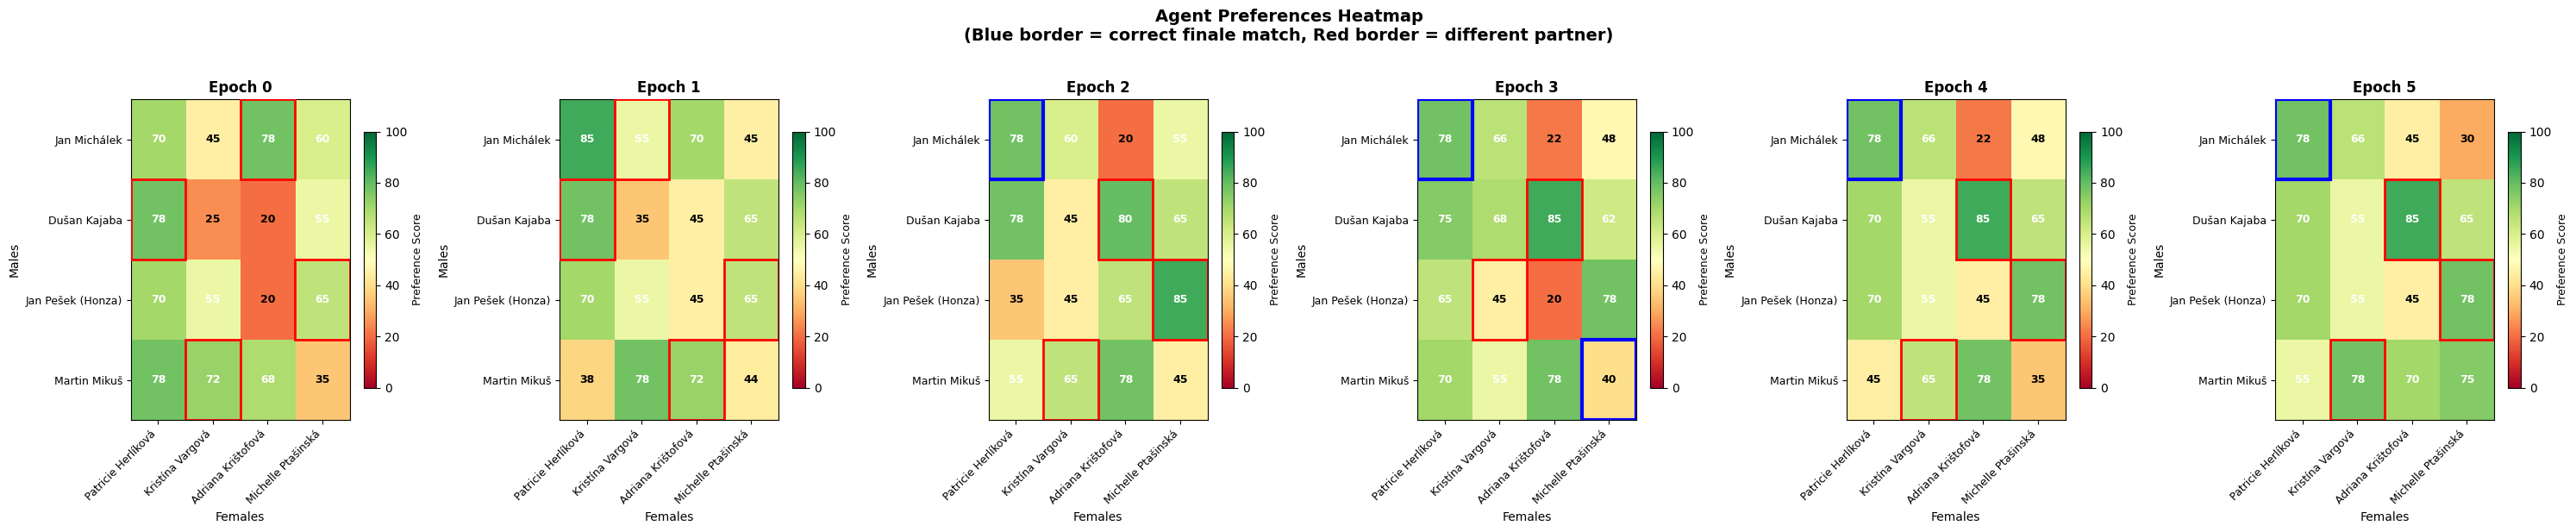

In [ ]:
# Preference Heatmap Grid
# One heatmap per epoch showing preference scores (males x females)
# Border colors: blue = correct finale match, red = different partner

import matplotlib.patches as patches

# Build lookup dictionaries
agent_by_id: dict[str, LoveIslandPerson] = {agent.id: agent for agent in results.agents}
female_ids: list[str] = [pair[0] for pair in results.finale_pairs]
male_ids: list[str] = [pair[1] for pair in results.finale_pairs]
female_names: list[str] = [agent_by_id[fid].full_name for fid in female_ids]
male_names: list[str] = [agent_by_id[mid].full_name for mid in male_ids]

# Expected partners from finale pairs (ground truth)
expected_partners: dict[str, str] = {
    male_id: female_id for female_id, male_id in results.finale_pairs
}

# Setup figure with one subplot per epoch
num_epochs: int = len(results.epoch_results)
fig, axes = plt.subplots(1, num_epochs, figsize=(5 * num_epochs, 6), squeeze=False)
axes = axes[0]

for ax, epoch_result in zip(axes, results.epoch_results):
    epoch = epoch_result.epoch

    # Build preference matrix: rows=males, columns=females
    pref_matrix = np.array(
        [
            [
                epoch_result.agent_preferences.get(mid, {}).get(fid, 0)
                for fid in female_ids
            ]
            for mid in male_ids
        ]
    )

    # Create heatmap
    im = ax.imshow(pref_matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=100)
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Preference Score", fontsize=9)

    # Axis labels
    ax.set_xticks(range(len(female_ids)))
    ax.set_xticklabels(female_names, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(male_ids)))
    ax.set_yticklabels(male_names, fontsize=9)
    ax.set_xlabel("Females", fontsize=10)
    ax.set_ylabel("Males", fontsize=10)
    ax.set_title(f"Epoch {epoch}", fontsize=12, fontweight="bold")

    # Add preference values as text in cells
    for i in range(len(male_ids)):
        for j in range(len(female_ids)):
            value = pref_matrix[i, j]
            text_color = "white" if value > 50 else "black"
            ax.text(
                j,
                i,
                f"{int(value)}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_color,
                fontweight="bold",
            )

    # Highlight partner selections with colored borders
    for i, male_id in enumerate(male_ids):
        partner_id = epoch_result.agent_partners.get(male_id)
        if partner_id in female_ids:
            j = female_ids.index(partner_id)
            is_correct = partner_id == expected_partners.get(male_id)
            border_color = "blue" if is_correct else "red"
            border_width = 3 if is_correct else 2

            rect = patches.Rectangle(
                (j - 0.5, i - 0.5),
                1,
                1,
                linewidth=border_width,
                edgecolor=border_color,
                facecolor="none",
                zorder=10,
            )
            ax.add_patch(rect)

# Overall title
fig.suptitle(
    "Agent Preferences Heatmap\n(Blue border = correct finale match, Red border = different partner)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

# Conclusion

From the simulation itself we observe an accuracy of 1/4, where just a single pair matched their real partners.

The closer examination of the preference heatmap however shows, that their real partners ranked the worst possible preference. That holds for Kristina and Dusan and Adriana and Honza. In the last case of Michelle and Martin, their common score was the lowest, however it increased pretty much and we cant rule the possibiity of them forming a couple if the simulation were to continue further.
This is an interesting progression of things and it is the opposite of the real-life results.
